<a href="https://colab.research.google.com/github/youssef1061/XAI-project/blob/main/Youssef_hatem_Maimaitijiang2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Maimaitijiang 2025 CatBoost


In [ ]:
MODEL_ID = "Youssef_Maimaitijiang2025_CatBoost"
MODEL_NAME = "Youssef_CatBoost_Maimaitijiang2025"

%pip -q install pandas numpy matplotlib seaborn scikit-learn shap lime xgboost catboost tensorflow joblib optuna imbalanced-learn

import os, warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if not hasattr(np, "bool"):
    np.bool = np.bool_
if not hasattr(np, "int"):
    np.int = int

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as e:
    print("Drive mount skipped:", e)

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve, average_precision_score, cohen_kappa_score
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import optuna
from catboost import CatBoostClassifier, Pool

import shap
from lime.lime_tabular import LimeTabularExplainer

sns.set(style="whitegrid")
RANDOM_STATE = 42
TARGET = "Diabetes"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def find_data_dir():
    candidates = [
        Path("/content/drive/MyDrive/BRFSS2015_processed"),
        Path("BRFSS2015_processed"),
        Path("artifacts"),
        Path(".")
    ]
    for d in candidates:
        if (d/"train.csv").exists() and (d/"test.csv").exists():
            return d
    raise FileNotFoundError("Cannot find train.csv and test.csv.")

DATA_DIR = find_data_dir()
OUTPUT_DIR = DATA_DIR / "final_model_outputs_high_accuracy" / MODEL_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Using DATA_DIR:", DATA_DIR)
print("Saving OUTPUT_DIR:", OUTPUT_DIR)

train_df = pd.read_csv(DATA_DIR/"train.csv")
test_df = pd.read_csv(DATA_DIR/"test.csv")
train_df = train_df.loc[:, ~train_df.columns.str.contains("^Unnamed")]
test_df = test_df.loc[:, ~test_df.columns.str.contains("^Unnamed")]

for c in train_df.columns:
    train_df[c] = pd.to_numeric(train_df[c], errors="coerce")
for c in test_df.columns:
    test_df[c] = pd.to_numeric(test_df[c], errors="coerce")

train_df = train_df.fillna(train_df.median(numeric_only=True))
test_df = test_df.fillna(train_df.median(numeric_only=True))

X_train_full = train_df.drop(columns=[TARGET])
y_train_full = train_df[TARGET].astype(int)
X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET].astype(int)
X_test = X_test[X_train_full.columns]

# Split into train/val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.15,
    stratify=y_train_full,
    random_state=RANDOM_STATE
)

feature_cols = list(X_train.columns)
classes = sorted(y_train_full.unique().tolist())
CLASS_NAMES = ["No Diabetes", "Prediabetes", "Diabetes"] if classes == [0,1,2] else [f"Class {c}" for c in classes]

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Class distribution (train):")
display(y_train.value_counts().sort_index().to_frame("train_count"))

Using DATA_DIR: /content/drive/MyDrive/BRFSS2015_processed
Saving OUTPUT_DIR: /content/drive/MyDrive/BRFSS2015_processed/final_model_outputs_high_accuracy/Youssef_Maimaitijiang2025_CatBoost
Train: (170046, 20) Val: (30009, 20) Test: (50014, 20)
Class distribution (train):


,train_count
Diabetes,
0,141578
1,4484
2,23984


## SMOTE Oversampling

In [ ]:
print("Before SMOTE:")
print(y_train.value_counts().sort_index())
print()

smote = SMOTE(random_state=RANDOM_STATE, sampling_strategy='auto')
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_train_smote).value_counts().sort_index())
print(f"\nTraining samples increased from {len(X_train):,} to {len(X_train_smote):,}")

Before SMOTE:
Diabetes
0    141578
1      4484
2     23984
Name: count, dtype: int64

After SMOTE:
Diabetes
0    141578
1    141578
2    141578
Name: count, dtype: int64

Training samples increased from 170,046 to 424,734


## Optuna Hyperparameter Tuning


In [ ]:
def optuna_objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 300, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'random_strength': trial.suggest_float('random_strength', 0.1, 5.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 2.0),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'loss_function': 'MultiClass',
        'eval_metric': 'TotalF1',
        'auto_class_weights': 'Balanced',
        'random_seed': RANDOM_STATE,
        'verbose': False,
        'early_stopping_rounds': 50,
    }


    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = []

    for fold_idx, (tr_idx, vl_idx) in enumerate(skf.split(X_train_smote, y_train_smote)):
        X_tr = X_train_smote.iloc[tr_idx] if hasattr(X_train_smote, 'iloc') else X_train_smote[tr_idx]
        y_tr = y_train_smote.iloc[tr_idx] if hasattr(y_train_smote, 'iloc') else y_train_smote[tr_idx]
        X_vl = X_train_smote.iloc[vl_idx] if hasattr(X_train_smote, 'iloc') else X_train_smote[vl_idx]
        y_vl = y_train_smote.iloc[vl_idx] if hasattr(y_train_smote, 'iloc') else y_train_smote[vl_idx]

        model = CatBoostClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=(X_vl, y_vl), verbose=False)

        y_pred = model.predict(X_vl)
        macro_f1 = f1_score(y_vl, y_pred, average='macro', zero_division=0)
        bal_acc = balanced_accuracy_score(y_vl, y_pred)
        score = 0.5 * macro_f1 + 0.5 * bal_acc
        scores.append(score)

    return np.mean(scores)

print("Starting Optuna hyperparameter tuning (10 trials)...")

study = optuna.create_study(direction='maximize', study_name='catboost_diabetes')
study.optimize(optuna_objective, n_trials=10, show_progress_bar=True)

print(f"\nBest trial score: {study.best_trial.value:.4f}")
print(f"Best params: {study.best_trial.params}")

[I 2026-05-12 16:38:04,933] A new study created in memory with name: catboost_diabetes


Starting Optuna hyperparameter tuning (10 trials)...


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-05-12 16:38:57,845] Trial 0 finished with value: 0.7132928762583718 and parameters: {'iterations': 451, 'learning_rate': 0.030983935523189805, 'depth': 7, 'l2_leaf_reg': 3.0029374111378266, 'random_strength': 3.0560666510174417, 'bagging_temperature': 0.817150400664193, 'border_count': 51}. Best is trial 0 with value: 0.7132928762583718.
[I 2026-05-12 16:42:56,979] Trial 1 finished with value: 0.8396521645898581 and parameters: {'iterations': 873, 'learning_rate': 0.09244917822478758, 'depth': 9, 'l2_leaf_reg': 6.796195385043484, 'random_strength': 0.3579044905649553, 'bagging_temperature': 0.2930154281107171, 'border_count': 156}. Best is trial 1 with value: 0.8396521645898581.
[I 2026-05-12 16:44:30,600] Trial 2 finished with value: 0.7118030557638564 and parameters: {'iterations': 1188, 'learning_rate': 0.024207678213374068, 'depth': 4, 'l2_leaf_reg': 6.119487025810622, 'random_strength': 3.7889857759538885, 'bagging_temperature': 0.9192913942991823, 'border_count': 193}. Be

##  Train Final Model with Best Hyperparameters

In [ ]:
best_params = study.best_trial.params
best_params.update({
    'loss_function': 'MultiClass',
    'eval_metric': 'TotalF1',
    'auto_class_weights': 'Balanced',
    'random_seed': RANDOM_STATE,
    'verbose': False,
    'early_stopping_rounds': 50,
})

print("Training final model with best hyperparameters...")
print(f"Parameters: {best_params}\n")

model = CatBoostClassifier(**best_params)
model.fit(X_train_smote, y_train_smote, eval_set=(X_val, y_val), verbose=False)
print("Model trained successfully!")
print(f"   Best iteration: {model.get_best_iteration()}")

Training final model with best hyperparameters...
Parameters: {'iterations': 1437, 'learning_rate': 0.11573892840214094, 'depth': 10, 'l2_leaf_reg': 4.751536627332363, 'random_strength': 0.4821208970192389, 'bagging_temperature': 1.3501823381395577, 'border_count': 44, 'loss_function': 'MultiClass', 'eval_metric': 'TotalF1', 'auto_class_weights': 'Balanced', 'random_seed': 42, 'verbose': False, 'early_stopping_rounds': 50}

✅ Model trained successfully!
   Best iteration: 168


##  Comprehensive Evaluation

,dataset,accuracy,balanced_accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,cohen_kappa,roc_auc_weighted,roc_auc_macro
0,Validation,0.814456,0.45227,0.448127,0.805635,0.458106,0.45227,0.316973,0.776612,0.731346
1,Test,0.815352,0.45271,0.449664,0.806471,0.464482,0.45271,0.319107,0.778082,0.730144



Classification Report — TEST SET
              precision    recall  f1-score   support

 No Diabetes     0.8847    0.9038    0.8942     41641
 Prediabetes     0.0800    0.0106    0.0187      1319
    Diabetes     0.4287    0.4437    0.4361      7054

    accuracy                         0.8154     50014
   macro avg     0.4645    0.4527    0.4497     50014
weighted avg     0.7992    0.8154    0.8065     50014



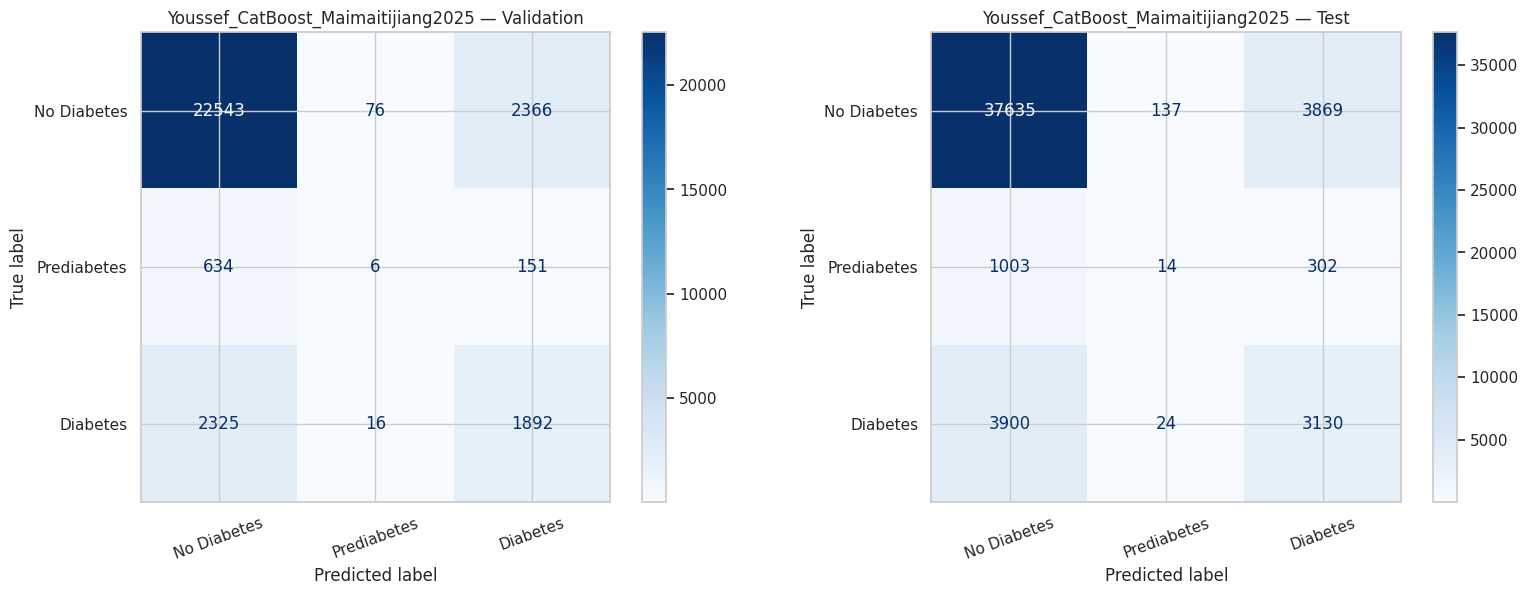

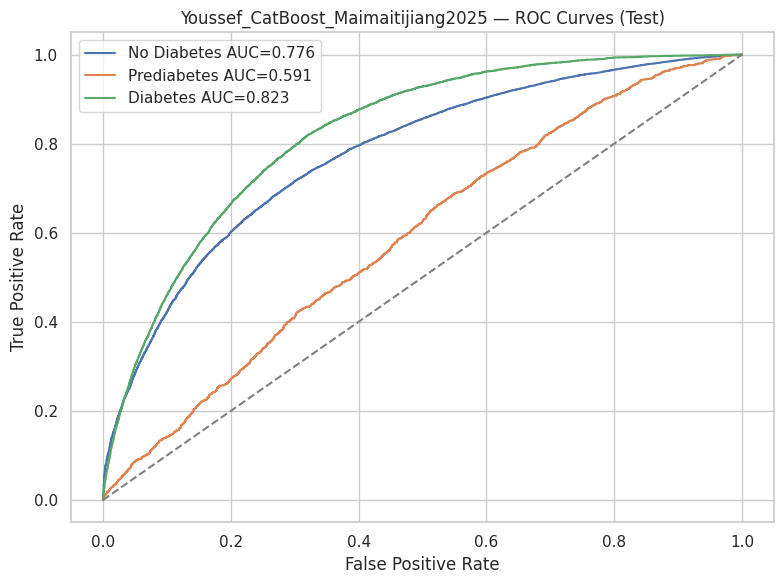

In [ ]:
def evaluate_model(model, X, y_true, dataset_name="Test"):
    """Comprehensive evaluation with all key metrics."""
    y_pred = model.predict(X).flatten().astype(int)
    y_prob = model.predict_proba(X)

    metrics = {
        "dataset": dataset_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "cohen_kappa": cohen_kappa_score(y_true, y_pred),
    }
    try:
        metrics["roc_auc_weighted"] = roc_auc_score(y_true, y_prob, multi_class="ovr", average="weighted")
        metrics["roc_auc_macro"] = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
    except Exception:
        metrics["roc_auc_weighted"] = np.nan
        metrics["roc_auc_macro"] = np.nan

    return metrics, y_pred, y_prob


val_metrics, y_val_pred, y_val_prob = evaluate_model(model, X_val, y_val, "Validation")
test_metrics, y_test_pred, y_test_prob = evaluate_model(model, X_test, y_test, "Test")

metrics_df = pd.DataFrame([val_metrics, test_metrics])
display(metrics_df)
metrics_df.to_csv(OUTPUT_DIR / f"{MODEL_NAME}_metrics.csv", index=False)


print(f"\n{'='*60}")
print(f"Classification Report — TEST SET")
print(f"{'='*60}")
print(classification_report(y_test, y_test_pred, target_names=CLASS_NAMES, zero_division=0, digits=4))


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (name, yt, yp) in zip(axes, [("Validation", y_val, y_val_pred), ("Test", y_test, y_test_pred)]):
    disp = ConfusionMatrixDisplay(confusion_matrix(yt, yp), display_labels=CLASS_NAMES)
    disp.plot(cmap="Blues", ax=ax, xticks_rotation=20)
    ax.set_title(f"{MODEL_NAME} — {name}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{MODEL_NAME}_confusion_matrices.png", dpi=200, bbox_inches="tight")
plt.show()


plt.figure(figsize=(8, 6))
for i, c in enumerate(classes):
    yb = (y_test == c).astype(int)
    fpr, tpr, _ = roc_curve(yb, y_test_prob[:, i])
    plt.plot(fpr, tpr, label=f"{CLASS_NAMES[i]} AUC={auc(fpr, tpr):.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"{MODEL_NAME} — ROC Curves (Test)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{MODEL_NAME}_roc.png", dpi=200, bbox_inches="tight")
plt.show()

###  Permutation Feature Importance (PFI)


Computing Permutation Feature Importance...


,feature,importance
1,HighBP,0.053402
15,BMI,0.033104
3,BMI_x_Age,0.032274
10,Income,0.018730
14,MetS_score,0.018022
18,TimeSinceCheckup,0.010284
0,GenHlth,0.006110
16,FINDRISC_score,0.006019
4,CV_burden_weighted,0.003969
9,SES_risk_score,0.002851


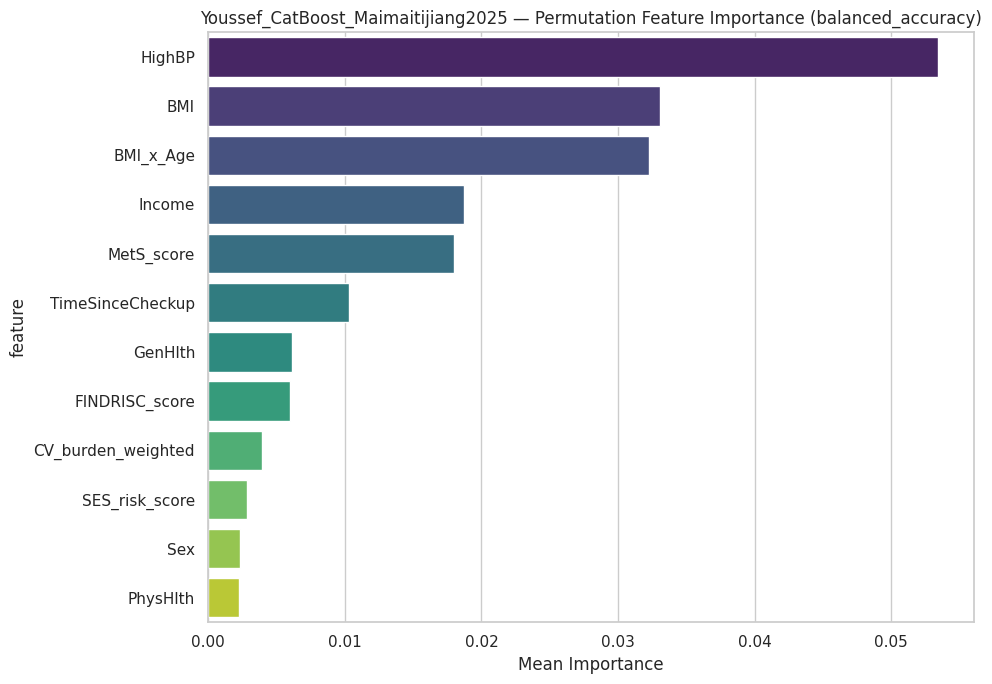

In [ ]:
print("Computing Permutation Feature Importance...")
pfi = permutation_importance(model, X_test, y_test,
                             scoring="balanced_accuracy",
                             n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
pfi_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": pfi.importances_mean
}).sort_values("importance", ascending=False)

display(pfi_df.head(15))
pfi_df.to_csv(OUTPUT_DIR / f"{MODEL_NAME}_pfi.csv", index=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=pfi_df.head(12), x="importance", y="feature", orient="h", palette="viridis")
plt.title(f"{MODEL_NAME} — Permutation Feature Importance (balanced_accuracy)")
plt.xlabel("Mean Importance")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{MODEL_NAME}_pfi.png", dpi=200, bbox_inches="tight")
plt.show()

###  Partial Dependence Plots (PDP)


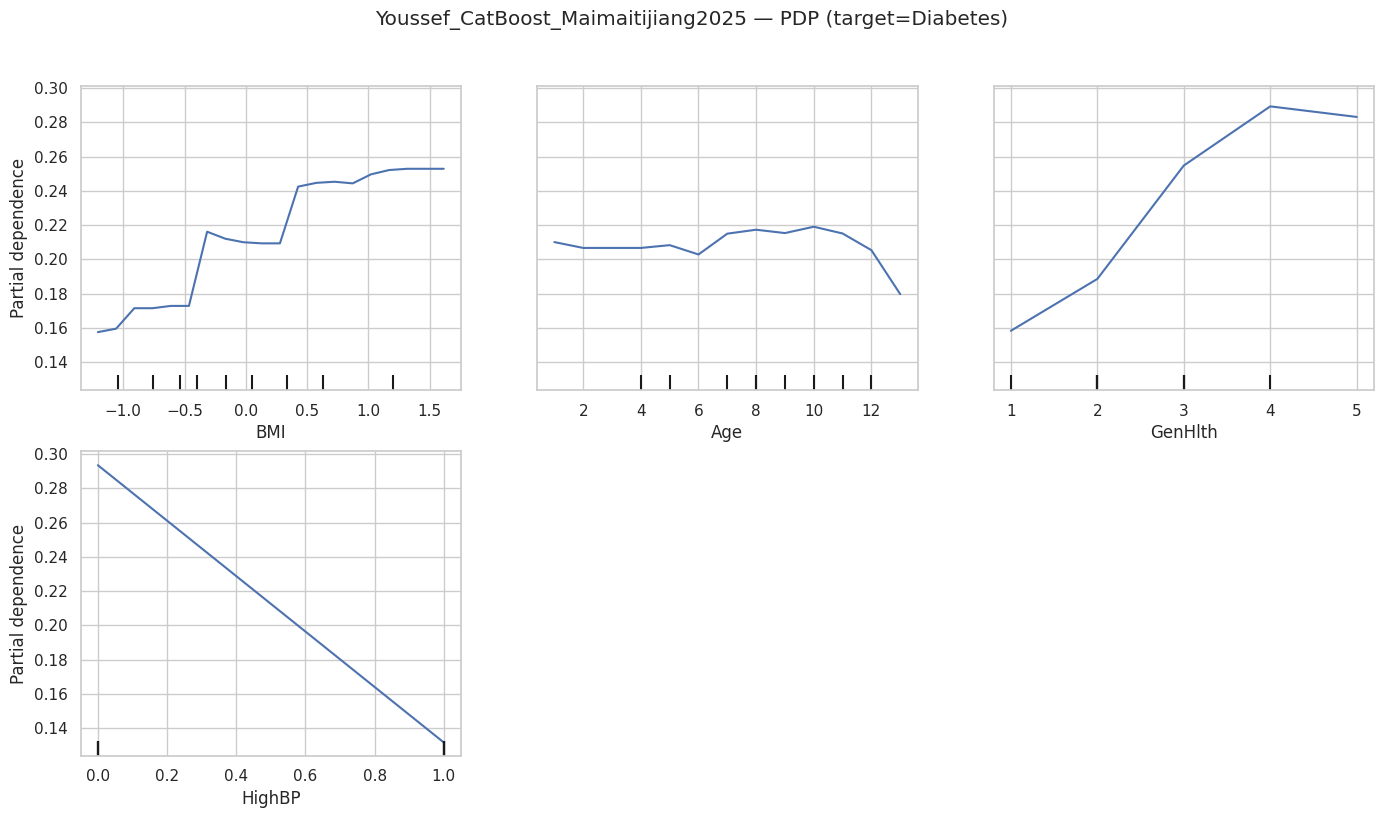

In [ ]:

top_feats = [f for f in ["BMI", "Age", "GenHlth", "HighBP"] if f in X_test.columns] or feature_cols[:4]
small = X_test.sample(min(1000, len(X_test)), random_state=RANDOM_STATE)

try:
    fig, ax = plt.subplots(figsize=(14, 8))
    PartialDependenceDisplay.from_estimator(model, small, top_feats, target=2,
                                            kind="average", grid_resolution=20, ax=ax)
    plt.suptitle(f"{MODEL_NAME} — PDP (target=Diabetes)", y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{MODEL_NAME}_pdp.png", dpi=200, bbox_inches="tight")
    plt.show()
except Exception as e:
    print("PDP failed:", e)

###  Individual Conditional Expectation (ICE)


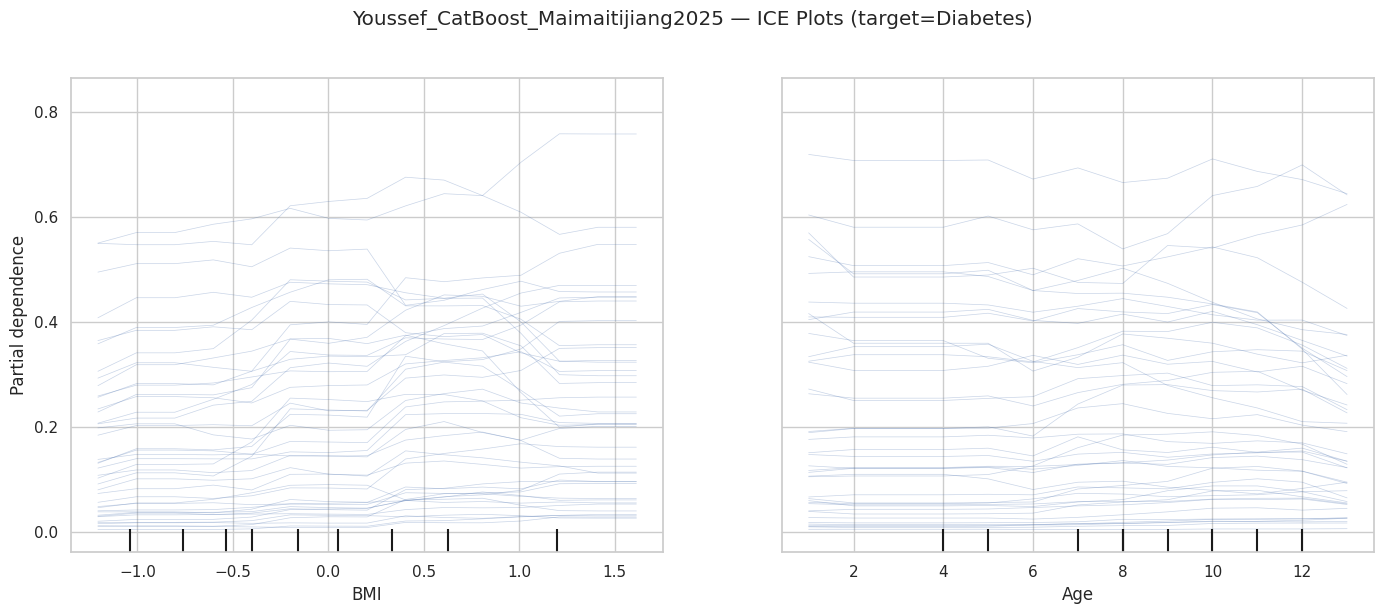

In [ ]:
try:
    fig, ax = plt.subplots(figsize=(14, 6))
    PartialDependenceDisplay.from_estimator(model, small, top_feats[:2], target=2,
                                            kind="individual", subsample=40,
                                            grid_resolution=15, random_state=RANDOM_STATE, ax=ax)
    plt.suptitle(f"{MODEL_NAME} — ICE Plots (target=Diabetes)", y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{MODEL_NAME}_ice.png", dpi=200, bbox_inches="tight")
    plt.show()
except Exception as e:
    print("ICE failed:", e)

### SHAP (SHapley Additive exPlanations)

Computing SHAP values (this may take a few minutes)...


  0%|          | 0/50 [00:00<?, ?it/s]

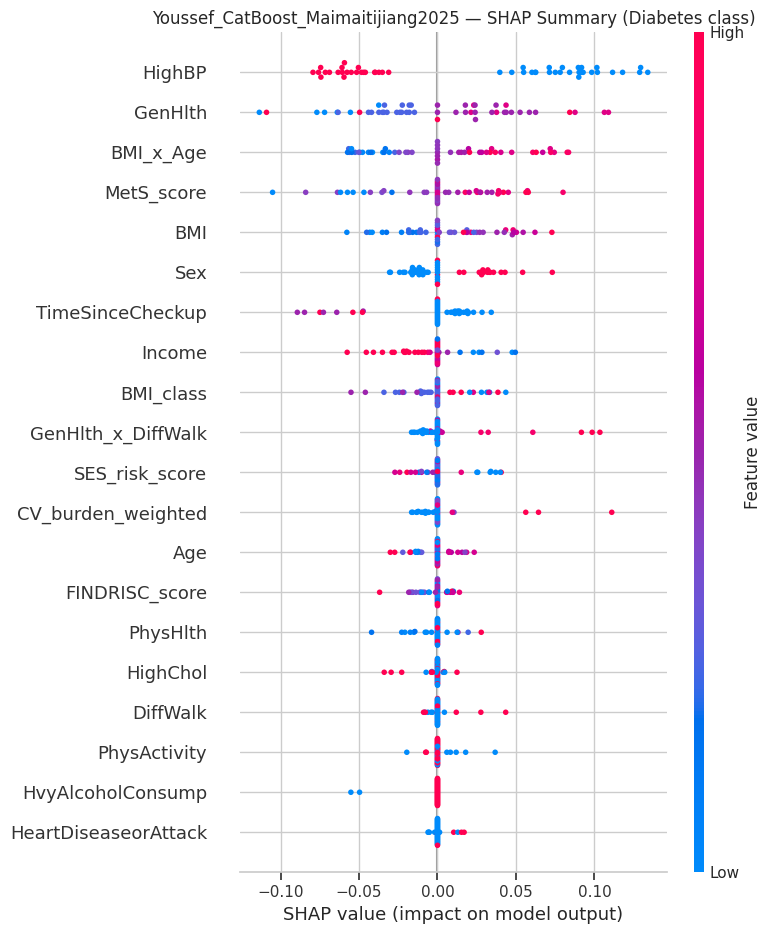

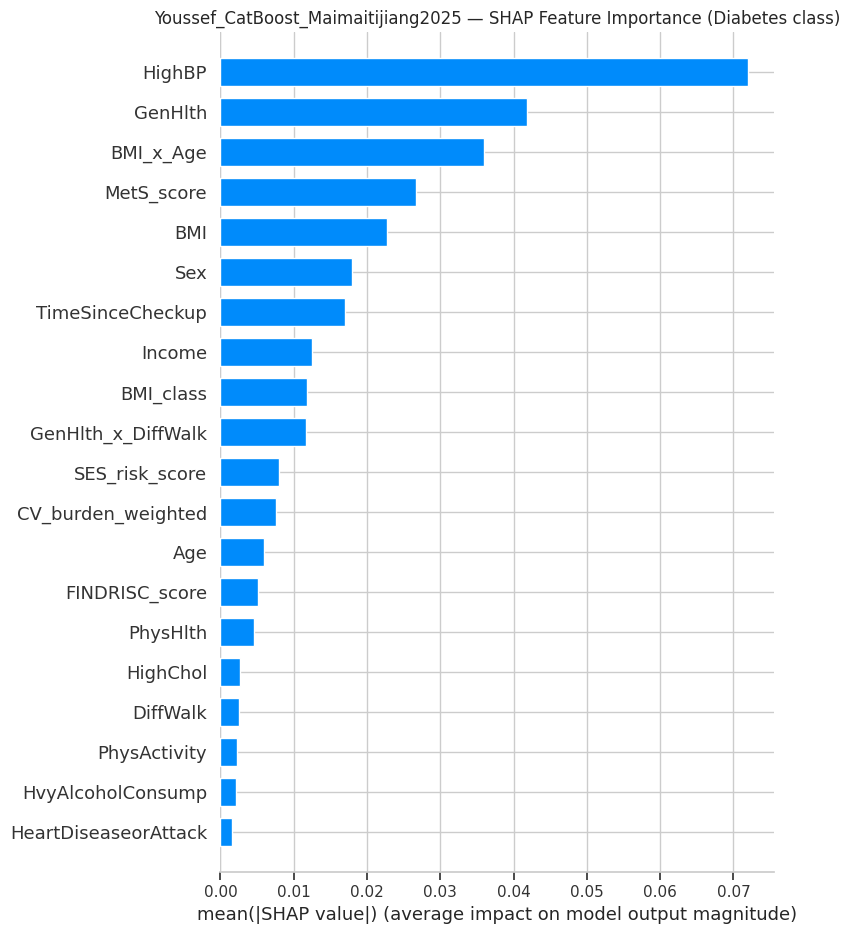

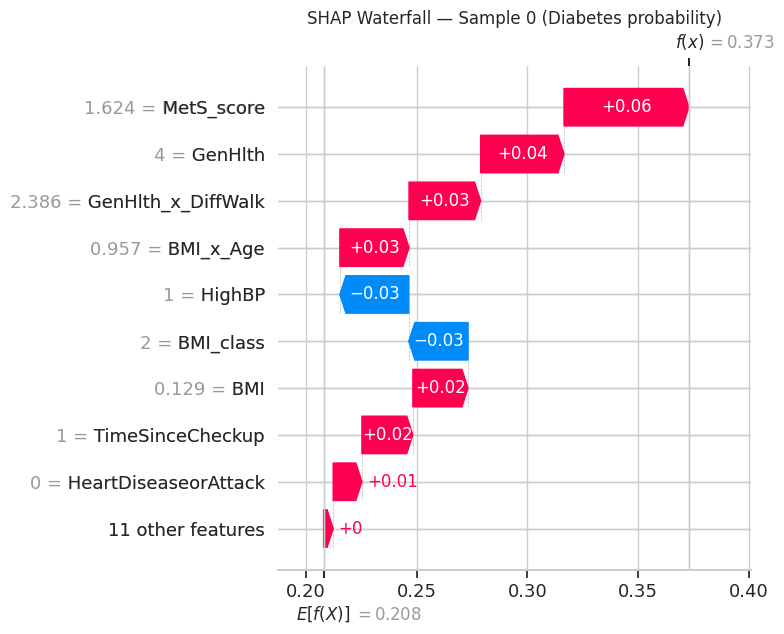

In [ ]:
print("Computing SHAP values (this may take a few minutes)...")
bg = shap.sample(X_train, min(50, len(X_train)), random_state=RANDOM_STATE)
ex_sample = shap.sample(X_test, min(50, len(X_test)), random_state=RANDOM_STATE)

# Explain probability of Diabetes class (class 2)
f_shap = lambda data: model.predict_proba(pd.DataFrame(data, columns=feature_cols))[:, 2]
explainer = shap.KernelExplainer(f_shap, bg)
shap_values = explainer.shap_values(ex_sample, nsamples=100)

# Global summary plot
shap.summary_plot(shap_values, ex_sample, feature_names=feature_cols, show=False)
plt.title(f"{MODEL_NAME} — SHAP Summary (Diabetes class)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{MODEL_NAME}_shap_summary.png", dpi=200, bbox_inches="tight")
plt.show()

# Bar plot of mean absolute SHAP values
shap.summary_plot(shap_values, ex_sample, feature_names=feature_cols,
                  plot_type="bar", show=False)
plt.title(f"{MODEL_NAME} — SHAP Feature Importance (Diabetes class)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{MODEL_NAME}_shap_bar.png", dpi=200, bbox_inches="tight")
plt.show()

# Local explanation — waterfall for first test sample
shap.waterfall_plot(shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=ex_sample.iloc[0].values,
    feature_names=feature_cols
), show=False)
plt.title("SHAP Waterfall — Sample 0 (Diabetes probability)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{MODEL_NAME}_shap_waterfall.png", dpi=200, bbox_inches="tight")
plt.show()

### LIME (Local Interpretable Model-agnostic Explanations)

In [ ]:
print("Computing LIME explanations...")
lime_explainer = LimeTabularExplainer(
    X_train.values, feature_names=feature_cols,
    class_names=CLASS_NAMES, discretize_continuous=True,
    mode="classification", random_state=RANDOM_STATE
)

# Explain 3 representative samples
sample_indices = [0, len(X_test)//2, len(X_test)-1]
for idx in sample_indices:
    try:
        exp = lime_explainer.explain_instance(
            X_test.iloc[idx].values,
            lambda x: model.predict_proba(pd.DataFrame(x, columns=feature_cols)),
            num_features=10, top_labels=3
        )
        exp.save_to_file(str(OUTPUT_DIR / f"{MODEL_NAME}_lime_sample_{idx}.html"))
        print(f"  LIME explanation saved for sample {idx}")
        # Show in notebook
        exp.show_in_notebook(show_table=True)
    except Exception as e:
        print(f"  LIME failed for sample {idx}:", e)

Computing LIME explanations...
  LIME explanation saved for sample 0


  LIME explanation saved for sample 25007


  LIME explanation saved for sample 50013


### 8.6 Surrogate Decision Tree

**Why:** Provides a simple, interpretable approximation of the complex model.

Training surrogate decision tree...
Surrogate fidelity: 0.913


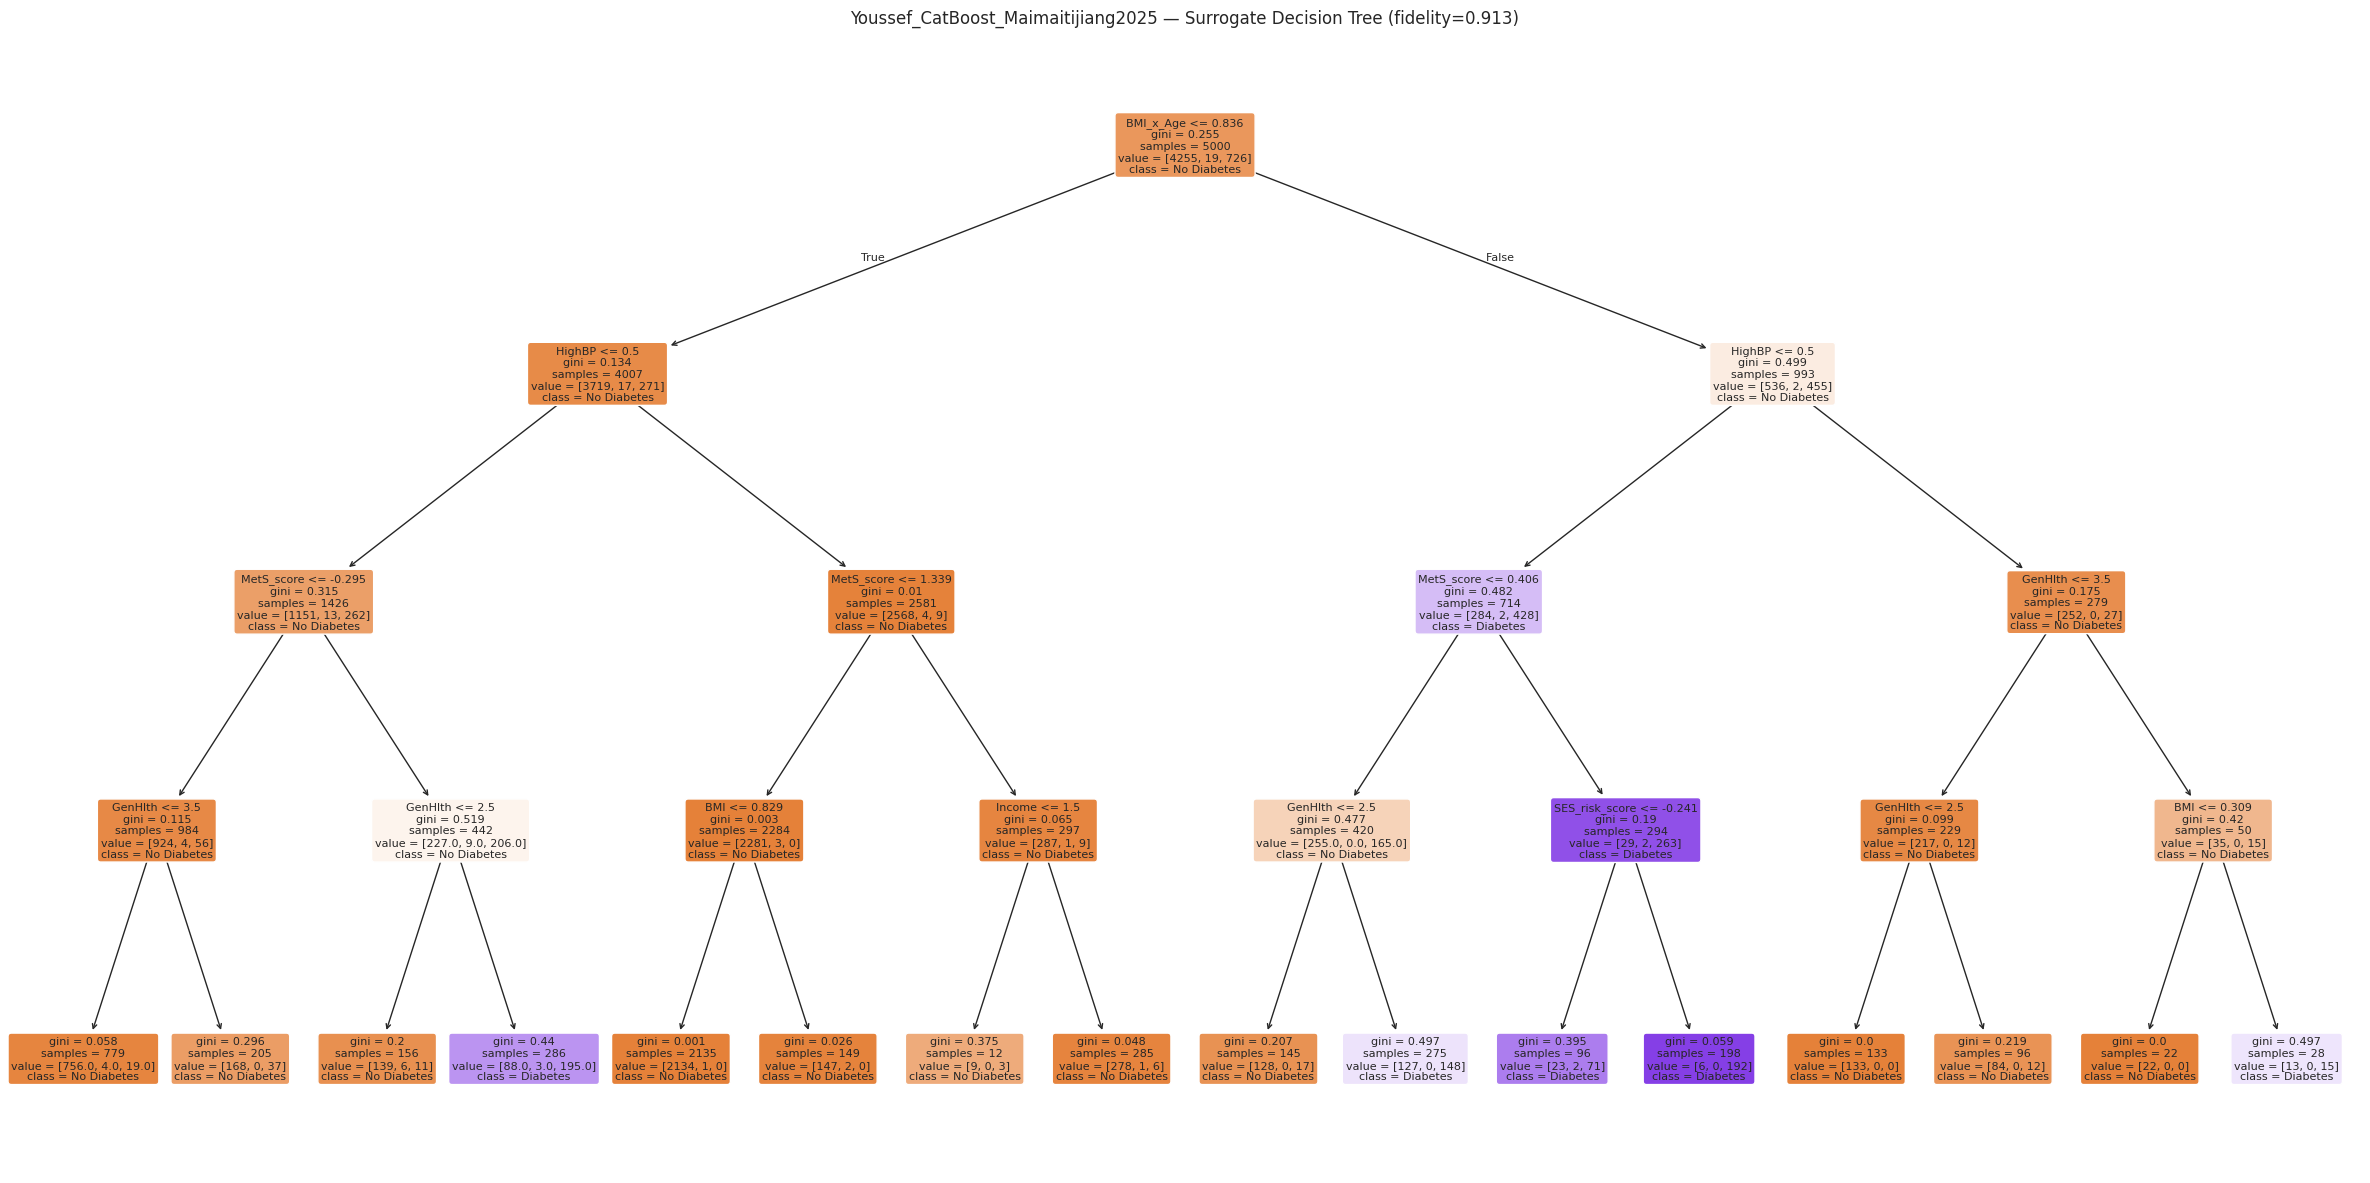

In [ ]:
print("Training surrogate decision tree...")
Xs = X_train.sample(min(5000, len(X_train)), random_state=RANDOM_STATE)
ys = model.predict(Xs).flatten().astype(int)

surrogate = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
surrogate.fit(Xs, ys)

fidelity = accuracy_score(
    model.predict(X_test).flatten().astype(int),
    surrogate.predict(X_test)
)
print(f"Surrogate fidelity: {fidelity:.3f}")

plt.figure(figsize=(24, 12))
plot_tree(surrogate, feature_names=feature_cols, class_names=CLASS_NAMES,
          filled=True, rounded=True, fontsize=8)
plt.title(f"{MODEL_NAME} — Surrogate Decision Tree (fidelity={fidelity:.3f})")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{MODEL_NAME}_surrogate.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
print("="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
print(f"\nTest Set Metrics:")
for k, v in test_metrics.items():
    if k != "dataset" and not np.isnan(v if isinstance(v, float) else 0):
        print(f"  {k:25s}: {v:.4f}")

print(f"\nModel saved to: {OUTPUT_DIR}")
model.save_model(str(OUTPUT_DIR / f"{MODEL_NAME}_best_model.cbm"))
print(" Model file saved!")

FINAL RESULTS SUMMARY

Test Set Metrics:
  accuracy                 : 0.8154
  balanced_accuracy        : 0.4527
  macro_f1                 : 0.4497
  weighted_f1              : 0.8065
  macro_precision          : 0.4645
  macro_recall             : 0.4527
  cohen_kappa              : 0.3191
  roc_auc_weighted         : 0.7781
  roc_auc_macro            : 0.7301

Model saved to: /content/drive/MyDrive/BRFSS2015_processed/final_model_outputs_high_accuracy/Youssef_Maimaitijiang2025_CatBoost
✅ Model file saved!
